In [48]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import imageio
from matplotlib.animation import FuncAnimation
import utils
import seaborn as sns
import pygmt
import matplotlib.colors as mcolors
from matplotlib import colors
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.gridspec as gridspec
from IPython.display import HTML
from scipy.interpolate import interp1d
from sklearn.metrics import mutual_info_score
import glob
import os
from scipy import signal
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from scipy.stats import pearsonr

plt.rcParams.update({'font.size': 12})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Individual model analysis

This is a Jupyter Notebook to analyze the outputs of Motorcycle models. The outputs are for a two-fault system and the models are 2D. 

Model output directory: twofaults_input_files
Subdirectory structure: Dc_XX/output_DcXX_Ykm
where XX is the value of Dc used in that set of simulations (e.g. Dc = 1 cm is Dc_01) and Y is the spacing between the faults in km (e.g. Y = 1 km is _1km).

Model suite
| D  (km)                           |$D_c$ (m)    | DX (m) | N2  |
|-------------------------------|-------|-----|------|
| 0.2,0.6,1,1.7,3,5,10,20,30,60,120          | 0.01  | 20  | 4096 |
| 0.2,0.6,1,1.7,3,5,10,20,30,60,120                   | 0.008 | 20  | 4096 |
| 0.2,0.6,1,1.7,3,5,10,20,30,60,120                   | 0.0063 | 10  | 8192 |
| 0.2,0.6,1,1.7,3,5,10,20,30,60,120                   | 0.005 | 10  | 8192 |
| 0.2,0.6,1,1.7,3,5,10,20,30,60,120                   | 0.0039 | 10  | 8192 |
| 0.2,0.6,1,1.7,3,5,10,20,30,60,120                   | 0.003 | 5  | 16384 |
| 0.2,0.6,1,1.7,3,5,10,20,30,60,120                   | 0.002 | 5  | 16384 |
| 0.2,0.6,1,1.7,3,5,10,20,30,60,120                   | 0.0014 | 2.5   | 32768 |
| 0.2,0.6,1,1.7,3,5,10,20,30,60,120                  | 0.001 | 2.5   | 32768 |

The only user-required inputs are in the cell below. 

In [49]:
#### this is the only cell that needs changing before running 
main_dir = "model_outputs/two_faults/antiplane/"
files_interest = ["Dc_01/output_Dc01_0.5km/"] 
loading_type = "Antiplane"
dc = 0.01 # Dc in RSF 
D = 0.5 # distance between the two parallel faults in kilometers
spin_up = utils.load_spinup_estimate("code_output_data/spinup_estimates.csv",
                                    loading_type, dc, D, default=200)  # yr, from evolution_interaction_metrics_with_time.ipynb

Loaded spin-up = 0.0 yr for Antiplane, Dc=0.01, D=0.5


In [50]:
cell_dict = {
    0.01: (20, 4096),
    0.008: (20, 4096),
    0.0063: (10, 8192),
    0.005: (10, 8192),
    0.0039: (10, 8192),
    0.003: (5, 16384),
    0.002: (5, 16384),
    0.0014: (2.5, 32768),
    0.001: (2.5, 32768) 
} # DX and N2 info for each model from Motorcycle shell scripts 

def downsample_grid(grid, dc):
    if dc > 0.005:
        return grid.coarsen(x=2, boundary='trim').mean()
    elif 0.0014 <= dc <= 0.005:      
        return grid.coarsen(x=3, boundary='trim').mean()
    else:
        return grid.coarsen(x=4, boundary='trim').mean()

In [51]:
DX, N2 = cell_dict[dc]
DX = [DX]
N2 = [N2]
cols = ['Index', 'Displacement', 'Col3', 'Col4', 'Col5', 'col', 'cplb','Slip Rate', 'Col7', 'Col8', 'Col9', 'Col10','Col11'] 
# time step conversion
time_step_rate = 20 # --export-netcdf-rate 20 \ ----- I am using the same in all models so this one shouldn't change..
grid_step_rate_horizontal = 4

# for calculating Ru
shear_mod = 30e9  # Shear modulus in Pa
a = 1e-2
b = a+4e-3
sigma_o = 100e6  # normal stress Pa
L = 5000 # rate-weakening length

feature = 'log10v' # tau, slip, log10v
fault1_path = main_dir + "fault-01-" + feature + ".grd"
DL = D/5
Ru = utils.estimate_Ru(shear_mod, dc, b, a, sigma_o, L)
titles = [f'Ru = {Ru:.1f}, D/L = {DL}, {loading_type}']

MODEL VISUALIZER

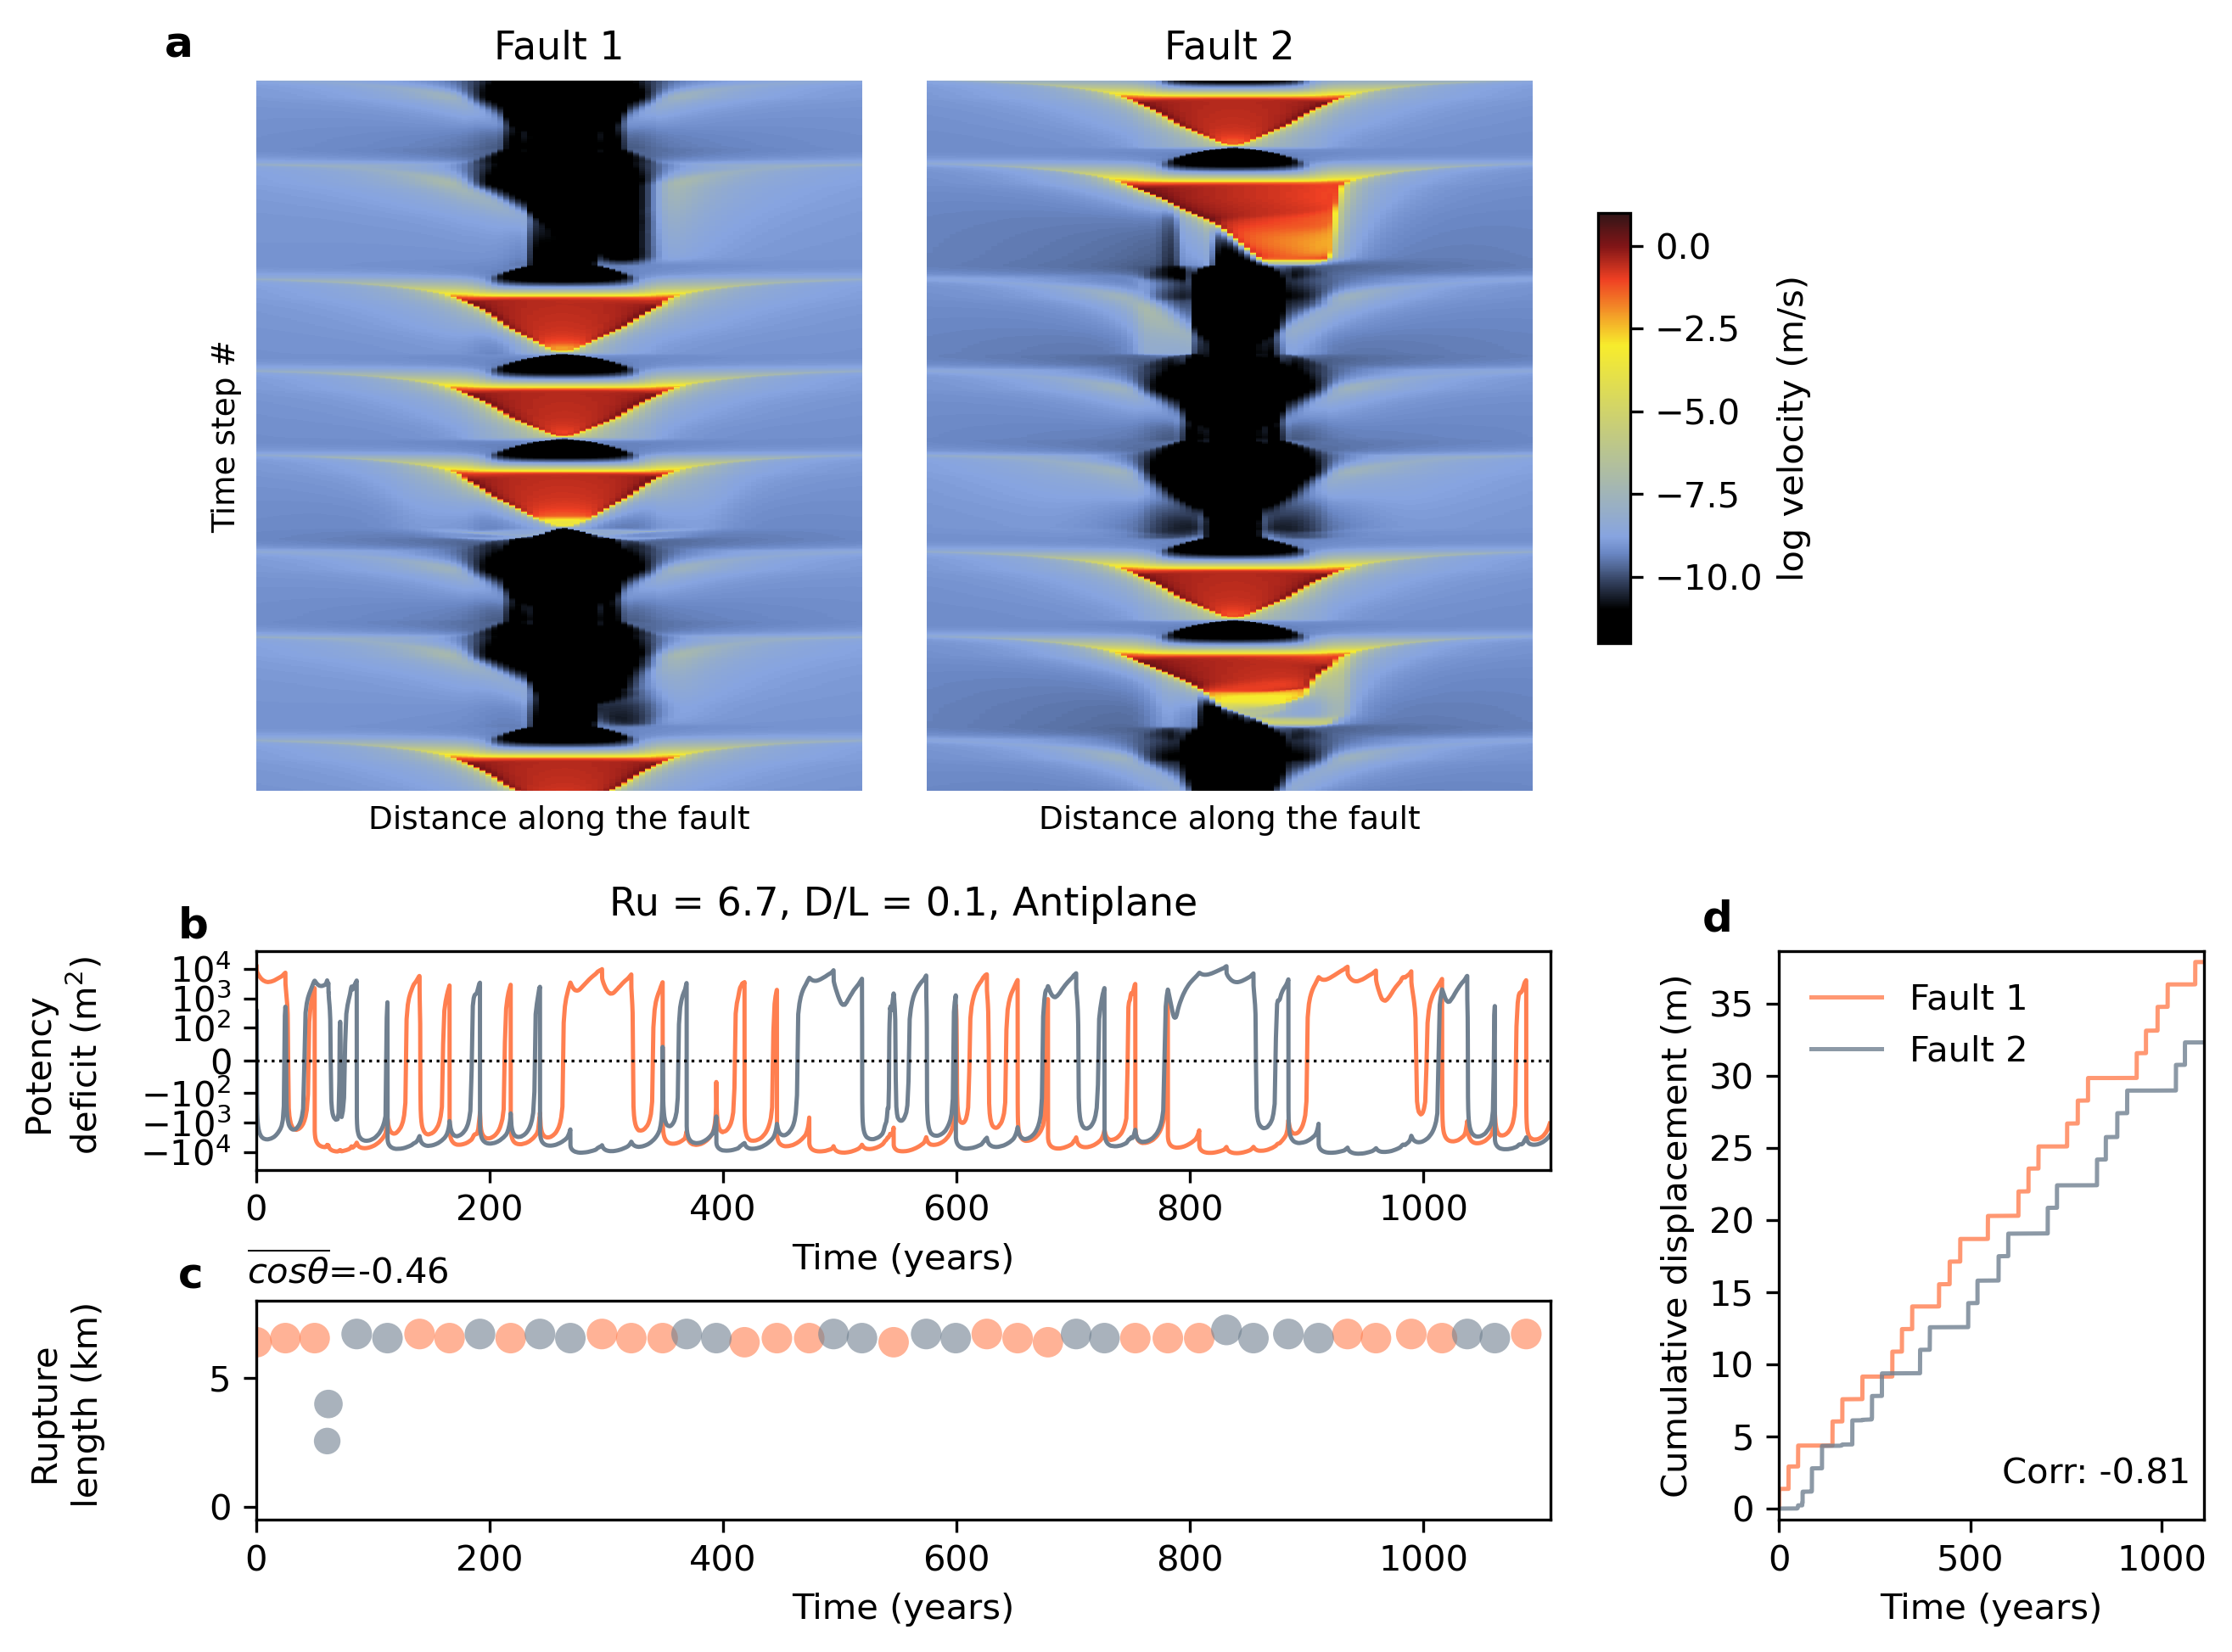

In [52]:
num_files = len(files_interest)
vmin = -12 # color limits
vmax = 1
cmap = plt.get_cmap('rocket')
cropped_cmap = colors.LinearSegmentedColormap.from_list('flare_cropped', cmap(np.linspace(0, 0.9, 256)))
m = 256  # Define the number of colors
cmap = mcolors.ListedColormap(utils.cycles_colormap(m))

for i, (file, DXi, N2i, titlei) in enumerate(zip(files_interest, DX, N2,titles)):
    file = file
    fig = plt.figure(figsize=(8.5, 6.5),dpi=300)
    # Main grid to separate rows
    gs_main = gridspec.GridSpec(2, 1, hspace=0.25, height_ratios=[2.5, 2],
                                left=0.08, right=0.98, top=0.95, bottom=0.08)
    
    # Top row with horizontal spacing between ax1 and ax2
    gs_top = gridspec.GridSpecFromSubplotSpec(1, 9, subplot_spec=gs_main[0], 
                                            wspace=0.4, hspace=0.2)
    # Bottom rows with horizontal spacing between left panels and right panel
    gs_bottom = gridspec.GridSpecFromSubplotSpec(2, 9, subplot_spec=gs_main[1],
                                            wspace=0.05, hspace=0.6, height_ratios=[1, 1])
    
    ax1 = fig.add_subplot(gs_top[0, 0:3])
    ax2 = fig.add_subplot(gs_top[0, 3:6]) 
    ax3 = fig.add_subplot(gs_bottom[0, 0:6])  # panel b - potency deficit
    ax4 = fig.add_subplot(gs_bottom[1, 0:6])  # panel c - rupture length
    ax7 = fig.add_subplot(gs_bottom[:, 7:9])  # panel d - cumulative displacement 
    ax1.text(-0.15, 1.02, 'a', transform=ax1.transAxes, fontsize=12, fontweight='bold', va='bottom', ha='left')
    ax3.text(-0.06, 1.02, 'b', transform=ax3.transAxes, fontsize=12, fontweight='bold', va='bottom', ha='left')
    ax4.text(-0.06, 1.02, 'c', transform=ax4.transAxes, fontsize=12, fontweight='bold', va='bottom', ha='left')
    ax7.text(-0.18, 1.02, 'd', transform=ax7.transAxes, fontsize=12, fontweight='bold', va='bottom', ha='left')
    
    
    # load time file csv to get timestep to real time conversion
    file_pattern = main_dir + file + 'patch-01-*.dat'
    matching_files = glob.glob(file_pattern)
    fault_data = pd.read_csv(matching_files[0], sep='\s+', header=None, names=cols)

    # velocity grids for visualization
    feature = 'log10v'
    fault1_path = main_dir + file + "fault-01-" + feature + ".grd"
    grid_fault1 = pygmt.load_dataarray(fault1_path, engine='netcdf4')
    fault2_path = main_dir + file + "fault-02-" + feature + ".grd"
    grid_fault2 = pygmt.load_dataarray(fault2_path, engine='netcdf4')
    delta_grid = time_step_rate   
    time_grid = fault_data['Index'].iloc[::int(delta_grid)].values

    # dwnsample grids for plotting
    grid_fault1 = downsample_grid(grid_fault1, dc)
    grid_fault2 = downsample_grid(grid_fault2, dc)

    sns.heatmap(grid_fault1, ax=ax1, cmap=cmap, vmin=vmin, vmax=vmax, cbar=False)
    sns.heatmap(grid_fault2, ax=ax2, cmap=cmap, vmin=vmin, vmax=vmax, cbar=False)
    num_rows = grid_fault1.shape[0]
    if DXi>=10:
        start_row = int(num_rows / 3)  
        end_row =  int(2 * num_rows / 4)  
    elif DXi<=5:
        start_row = int(num_rows / 3.5) 
        end_row = int(2 * num_rows / 3.5)   
    ax1.set_ylim(start_row, end_row)
    ax2.set_ylim(start_row, end_row)
    x_lim1 = int(grid_fault1.shape[1] * 0.4) # removing 30% of grid on both edges on x axis
    x_lim2 = int(grid_fault1.shape[1] * 0.6)
    ax1.set_xlim(x_lim1, x_lim2)
    ax2.set_xlim(x_lim1, x_lim2)
    ax1.set_xticks([])
    ax1.set_yticks([])
    ax2.set_xticks([])
    ax2.set_yticks([])    
    ax1.set_title('Fault 1', fontsize=11, fontweight='normal')
    ax2.set_title('Fault 2', fontsize=11, fontweight='normal')
    ax1.set_xlabel('Distance along the fault', fontsize=9)
    ax2.set_xlabel('Distance along the fault', fontsize=9)
    ax1.set_ylabel('Time step #', fontsize=9)

    cbar_ax = fig.add_axes([0.7, 0.61, 0.015, 0.26])
    cbar = fig.colorbar(ax1.collections[0], cax=cbar_ax, location="right", shrink=0.25, aspect=25)
    cbar.set_label("log velocity (m/s)", fontsize=10)
    cbar.ax.tick_params(labelsize=10)

    # make catalog
    grid1_masked = np.ma.masked_where(grid_fault1 < -3.5, grid_fault1) # subset areas where velocity>seismic slip to isolate events
    grid2_masked = np.ma.masked_where(grid_fault2 < -3.5, grid_fault2)
    grid1_masked = grid1_masked.filled(np.nan) # for viz in seaborn fill unmasked areas with nan
    grid2_masked = grid2_masked.filled(np.nan)
    timestep_event_fault1, rupture_length_pixels_fault1, group_id_fault1, total_pixels_fault1_xdir,pixel_size = utils.find_events(grid1_masked,DXi,N2i,"No")
    timestep_event_fault2, rupture_length_pixels_fault2, group_id_fault2, total_pixels_fault2_xdir,pixel_size  = utils.find_events(grid2_masked,DXi,N2i,"No")
    time_f1 = time_grid[timestep_event_fault1]
    time_f2 = time_grid[timestep_event_fault2]
    rupture_length_fault1 = np.array(rupture_length_pixels_fault1) 
    rupture_length_fault2 = np.array(rupture_length_pixels_fault2) 

    # load slip grids and calculate potency
    feature = 'slip'
    fault1_path = main_dir + file + "fault-01-" + feature + ".grd"
    fault2_path = main_dir + file + "fault-02-" + feature + ".grd"
    grid_fault1 = pygmt.load_dataarray(fault1_path, engine='netcdf4')
    grid_fault2 = pygmt.load_dataarray(fault2_path, engine='netcdf4')
    grid_fault1 = downsample_grid(grid_fault1, dc) # downsample slip grids
    grid_fault2 = downsample_grid(grid_fault2, dc)
    potency_fault1 = np.array(utils.potency(grid_fault1, DXi*grid_step_rate_horizontal))
    potency_fault2 = np.array(utils.potency(grid_fault2, DXi*grid_step_rate_horizontal))
    
    if len(potency_fault1)!=len(time_grid):
        time_grid = time_grid[:-1]
        
    # remove spin-up period 
    time_cutoff = spin_up * 365 * 24 * 60 * 60
    cutoff_index = np.where(time_grid >= time_cutoff)[0][0]
    time_grid = time_grid[cutoff_index:]
    potency_fault1 = potency_fault1[cutoff_index:]
    potency_fault2 = potency_fault2[cutoff_index:]
    time_f1 = time_f1[time_f1 >= time_cutoff]
    time_f2 = time_f2[time_f2 >= time_cutoff]
    rupture_length_fault1 = rupture_length_fault1[len(rupture_length_fault1) - len(time_f1):]
    rupture_length_fault2 = rupture_length_fault2[len(rupture_length_fault2) - len(time_f2):]
    
    # remove ruptures that are 4 cells only (1 cell in here because of MTC downsampling) -- artifacts from masking
    ok_size_rupture_idx1 = np.where(rupture_length_fault1 > 3)[0]
    ok_size_rupture_idx2 = np.where(rupture_length_fault2 > 3)[0]
    time_f1_catalog = time_f1[ok_size_rupture_idx1]
    time_f2_catalog = time_f2[ok_size_rupture_idx2]
    rupture_length_fault1 = rupture_length_fault1[ok_size_rupture_idx1]
    rupture_length_fault2 = rupture_length_fault2[ok_size_rupture_idx2]
    
    # calculate order parameter R 
    index_full_ruptures_f1 = np.where((rupture_length_fault1 * pixel_size) / 1000 > 4.5)[0]
    index_full_ruptures_f2 = np.where((rupture_length_fault2 * pixel_size) / 1000 > 4.5)[0]
    time_f1_full = time_f1_catalog[index_full_ruptures_f1]
    time_f2_full = time_f2_catalog[index_full_ruptures_f2]
    phase = np.array([utils.get_phase(t, time_f1_full/365/24/60/60) for t in time_f2_full/365/24/60/60])
    phase = phase[~np.isnan(phase)]
    R_order = utils.get_order_parameter(phase)
    R = [R_order]
    
    # detrend potency using linear trend
    coeffs1 = np.polyfit(time_grid, potency_fault1, 1)
    coeffs2 = np.polyfit(time_grid, potency_fault2, 1)
    trend1 = np.polyval(coeffs1, time_grid)
    trend2 = np.polyval(coeffs2, time_grid)
    potency_deficit_fault1 = potency_fault1 - trend1
    potency_deficit_fault2 = potency_fault2 - trend2
    ax3.plot(time_grid/365/24/60/60,-potency_deficit_fault1, color='coral',linewidth=1.2, label='Fault 1')
    ax3.plot(time_grid/365/24/60/60,-potency_deficit_fault2, color='slategray',linewidth=1.2, label='Fault 2')
    ax3.axhline(0,linestyle=':',c='black', linewidth=0.8)
    ax3.set_xlabel('Time (years)', fontsize=10)
    ax3.set_title(titlei, fontsize=11, pad=10)
    ax3.set_xlim(spin_up,time_years.max())  
    ax3.set_ylim(-40000,40000)  
    ax3.set_yscale('symlog', linthresh=1e2)
    ax3.set_ylabel('Potency \n deficit (m$^2$)', fontsize=10, labelpad=10)
    ax3.tick_params(labelsize=10)
    scale_factor = 20
    
    # plot catalog
    ax4.scatter(time_f1_catalog/365/24/60/60, (rupture_length_fault1 * pixel_size) / 1000,
                    c='coral', s=scale_factor * np.log(rupture_length_fault1 + 1), alpha=0.6, edgecolor='none')
    ax4.scatter(time_f2_catalog/365/24/60/60, (rupture_length_fault2 * pixel_size) / 1000,
                    c='slategray', s=scale_factor * np.log(rupture_length_fault2 + 1), alpha=0.6, edgecolor='none')
    ax4.set_xlim(spin_up,time_years.max())
    ax4.set_ylim(-0.5, 8)
    ax4.set_xlabel('Time (years)', fontsize=10)
    ax4.set_ylabel('Rupture \n length (km)', fontsize=10, labelpad=10)
    ax4.tick_params(labelsize=10)
    fig.align_ylabels([ax3, ax4])
    fig.text(0.076, 0.23, r'$\overline{cos\theta}$=' + f'{R_order:.2f}', 
            fontsize=10, verticalalignment='center', horizontalalignment='left')

    # displacement data 
    fault_data_f1 = pd.read_csv(glob.glob(main_dir + file + 'patch-01-*.dat')[1], # [1] for fault midpoint, [0] and [2] for edges of RW zone
                                header=None, names=cols, sep='\s+')
    fault_data_f2 = pd.read_csv(glob.glob(main_dir + file + 'patch-02-*.dat')[1], 
                                header=None, names=cols, sep='\s+')
    
    fault_data_f1['Time (Years)'] = fault_data_f1['Index'].apply(utils.seconds_to_years)
    fault_data_f2['Time (Years)'] = fault_data_f2['Index'].apply(utils.seconds_to_years)
    
    cum_disp_f1 = fault_data_f1['Displacement']
    time_years_f1 = fault_data_f1['Time (Years)']
    cum_disp_f2 = fault_data_f2['Displacement']
    time_years_f2 = fault_data_f2['Time (Years)']

    # detrend displacement
    # Step 1: filter to time >= spin_up
    time_years = time_years_f1.values
    time_mask = time_years >= spin_up
    time_cropped = time_years[time_mask]
    cum_disp_f1_cropped = cum_disp_f1.values[time_mask]
    cum_disp_f2_cropped = cum_disp_f2.values[time_mask]
    # Step 2: resample to regular 1-year intervals
    time_start = np.ceil(time_cropped.min())  # round up to next whole year
    time_end = np.floor(time_cropped.max())   # round down to last whole year
    time_regular = np.arange(time_start, time_end + 1, 1.0)  # 1 year sampling
    # interpolate both signals onto regular time grid
    interp_f1 = interp1d(time_cropped, cum_disp_f1_cropped, kind='linear')
    interp_f2 = interp1d(time_cropped, cum_disp_f2_cropped, kind='linear')
    cum_disp_f1_regular = interp_f1(time_regular)
    cum_disp_f2_regular = interp_f2(time_regular)  
    # Step 3: fit and subtract linear trend for each fault
    coeffs_disp1 = np.polyfit(time_regular, cum_disp_f1_regular, 1)
    coeffs_disp2 = np.polyfit(time_regular, cum_disp_f2_regular, 1)
    trend_disp1 = np.polyval(coeffs_disp1, time_regular)
    trend_disp2 = np.polyval(coeffs_disp2, time_regular)
    cum_disp_f1_detrended = cum_disp_f1_regular - trend_disp1
    cum_disp_f2_detrended = cum_disp_f2_regular - trend_disp2
    # Step 4: correlation coefficient on detrended displacements
    disp_corr, _ = pearsonr(cum_disp_f1_detrended, cum_disp_f2_detrended)
    ax7.plot(time_years_f1, cum_disp_f1, color='coral', alpha=0.8, linewidth=1.2, label='Fault 1')
    ax7.plot(time_years_f2, cum_disp_f2, color='slategray', alpha=0.8, linewidth=1.2, label='Fault 2')
    ax7.set_xlabel('Time (years)',fontsize=10)
    ax7.set_ylabel('Cumulative displacement (m)',fontsize=10)
    ax7.set_xlim(spin_up, time_years.max())
    mask_f1 = (time_years_f1 >= spin_up) & (time_years_f1 <= time_years_f1.max())
    mask_f2 = (time_years_f2 >= spin_up) & (time_years_f2 <= time_years_f2.max())
    y_min = min(cum_disp_f1[mask_f1].min(), cum_disp_f2[mask_f2].min())
    y_max = max(cum_disp_f1[mask_f1].max(), cum_disp_f2[mask_f2].max())
    y_range = y_max - y_min
    ax7.set_ylim(y_min - 0.02*y_range, y_max + 0.02*y_range)
    
    ax7.legend(loc='upper left', fontsize=10, frameon=False)
    ax7.tick_params(labelsize=10)
    ax7.text(0.97, 0.05, f'Corr: {disp_corr:.2f}', transform=ax7.transAxes, 
            fontsize=10, verticalalignment='bottom', horizontalalignment='right')

    titlei = titlei.replace('$', '').replace('_', '').replace('/', '')
    plt.savefig(r'Summary figures/' + titlei +'.png',bbox_inches='tight')

Text(0, 0.5, 'Detrended displacement')

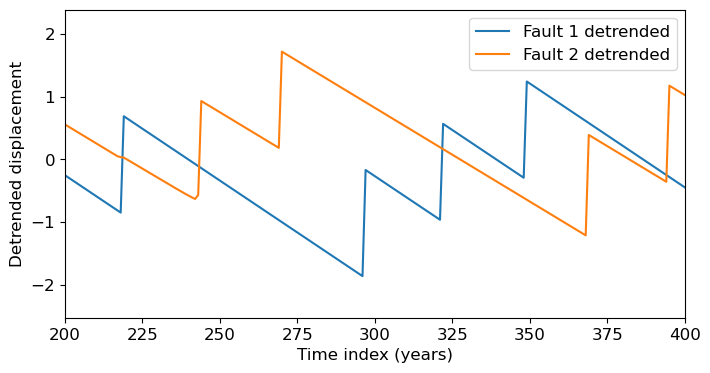

In [53]:
plt.figure(figsize=(8, 4))
plt.plot(cum_disp_f1_detrended, label='Fault 1 detrended')
plt.plot(cum_disp_f2_detrended, label='Fault 2 detrended')
plt.xlim(200,400)
plt.legend()
plt.xlabel('Time index (years)')
plt.ylabel('Detrended displacement')

### Export data to csv

In [54]:
corr_file = "code_output_data/corr_coefficient.csv"
if not os.path.isfile(corr_file):
    cols = ["Loading", "Dc", "D", "Correlation coefficient", "Spin-up (years)"]
    corr_database = pd.DataFrame(columns=cols)
    corr_database.to_csv(corr_file, index=False)
else:
    corr_database = pd.read_csv(corr_file)
existing_combination = corr_database[(corr_database['Dc'] == dc) & (corr_database['D'] == D) & (corr_database['Loading'] == loading_type)]
if not existing_combination.empty:
    corr_database = corr_database[~((corr_database['Dc'] == dc) & (corr_database['D'] == D) & (corr_database['Loading'] == loading_type))]
    print(f"Removed existing rows with Dc={dc} and D={D}.")

corr_sim_i = pd.DataFrame({
    'Loading': [loading_type],
    'Dc': [dc], 
    'D': [D],    
    'Correlation coefficient': disp_corr,
    'Spin-up (years)': [spin_up]
})

new_rows = pd.concat([corr_sim_i], ignore_index=True)
catalog_df = pd.concat([corr_database, new_rows], ignore_index=True)
catalog_df.to_csv(corr_file, index=False)
print("New row added to correlation coefficient parameter file.csv")

Removed existing rows with Dc=0.01 and D=0.5.
New row added to correlation coefficient parameter file.csv


In [55]:
corr_file = "code_output_data/alignment_coefficient_event_times.csv"
if not os.path.isfile(corr_file):
    cols = ["Loading", "Dc", "D", "Alignment coefficient", "Spin-up (years)"]
    corr_database = pd.DataFrame(columns=cols)
    corr_database.to_csv(corr_file, index=False)
else:
    corr_database = pd.read_csv(corr_file)
existing_combination = corr_database[(corr_database['Dc'] == dc) & (corr_database['D'] == D) & (corr_database['Loading'] == loading_type)]
if not existing_combination.empty:
    corr_database = corr_database[~((corr_database['Dc'] == dc) & (corr_database['D'] == D) & (corr_database['Loading'] == loading_type))]
    print(f"Removed existing rows with Dc={dc} and D={D}.")

corr_sim_i = pd.DataFrame({
    'Loading': [loading_type],
    'Dc': [dc], 
    'D': [D],    
    'Alignment coefficient': R,
    'Spin-up (years)': [spin_up]
})

new_rows = pd.concat([corr_sim_i], ignore_index=True)
catalog_df = pd.concat([corr_database, new_rows], ignore_index=True)
catalog_df.to_csv(corr_file, index=False)
print("New row added to alignment coefficient file.csv")

Removed existing rows with Dc=0.01 and D=0.5.
New row added to alignment coefficient file.csv
